In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
from google.colab import files


uploaded = files.upload()


Saving gender_submission.csv to gender_submission.csv
Saving test.csv to test.csv
Saving train.csv to train.csv


In [7]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
gender_submission = pd.read_csv('gender_submission.csv')

# Merge test with gender_submission to get 'Survived' column for analysis
test_full = pd.merge(test, gender_submission, on='PassengerId')

In [8]:
# Info and description
print("=== Train Dataset Info ===")
train.info()

print("\n=== Train Dataset Description ===")
display(train.describe(include='all'))

# Value counts for key columns
print("\n=== Survived Value Counts ===")
print(train['Survived'].value_counts())

print("\n=== Sex Value Counts ===")
print(train['Sex'].value_counts())

print("\n=== Embarked Value Counts ===")
print(train['Embarked'].value_counts())


=== Train Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== Train Dataset Description ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN



=== Survived Value Counts ===
Survived
0    549
1    342
Name: count, dtype: int64

=== Sex Value Counts ===
Sex
male      577
female    314
Name: count, dtype: int64

=== Embarked Value Counts ===
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


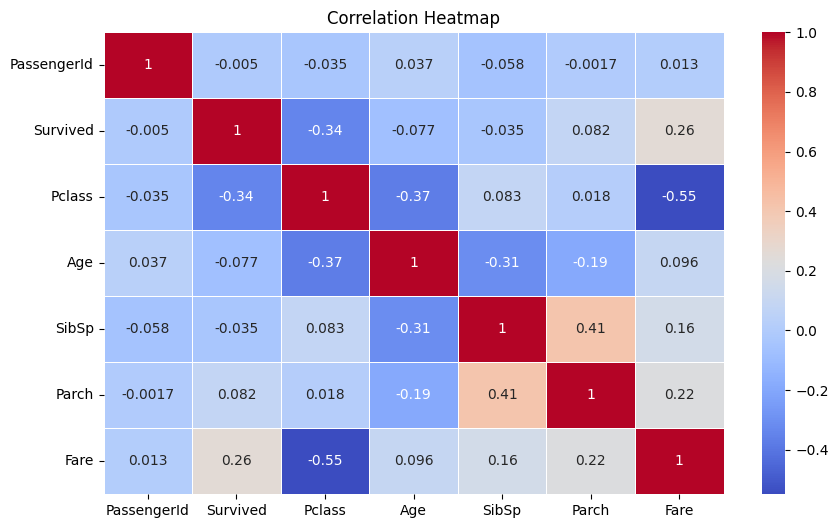

In [9]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()




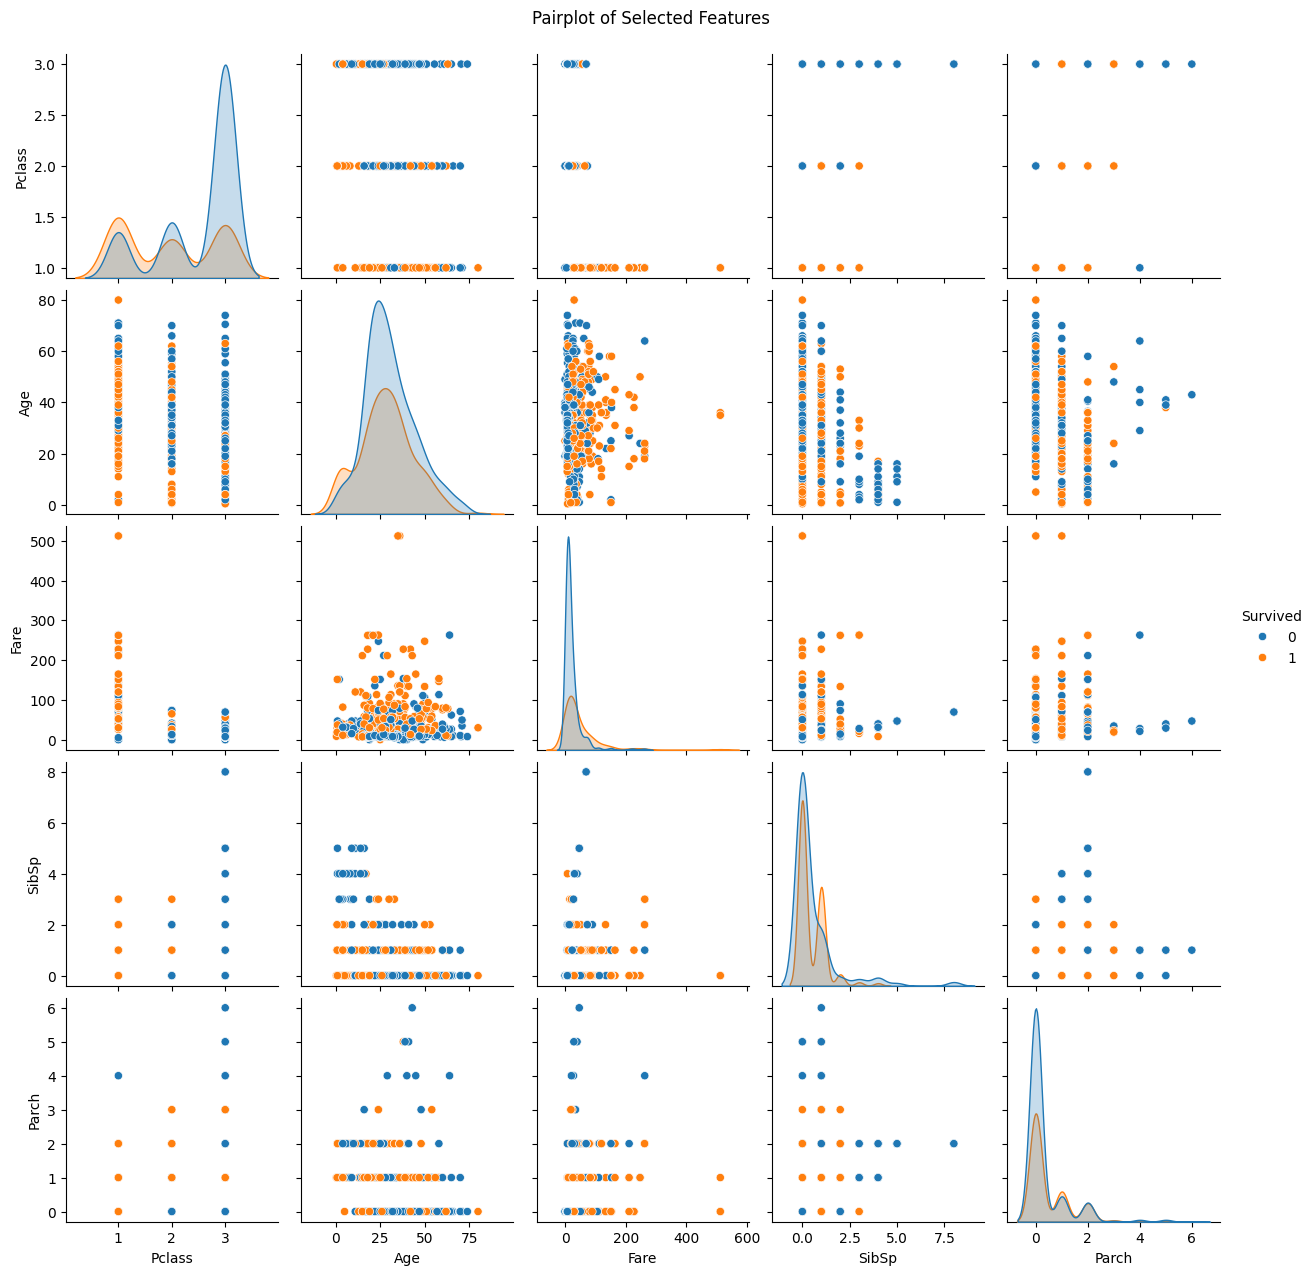

In [10]:
# Pairplot of key numeric features
sns.pairplot(train[['Survived', 'Pclass', 'Age', 'Fare', 'SibSp', 'Parch']], hue='Survived')
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()

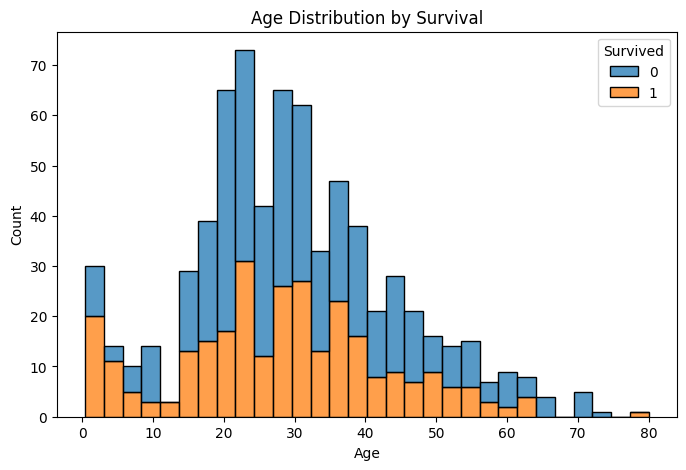

In [11]:
# Histogram - Age
plt.figure(figsize=(8, 5))
sns.histplot(data=train, x='Age', hue='Survived', multiple='stack', bins=30)
plt.title("Age Distribution by Survival")
plt.show()


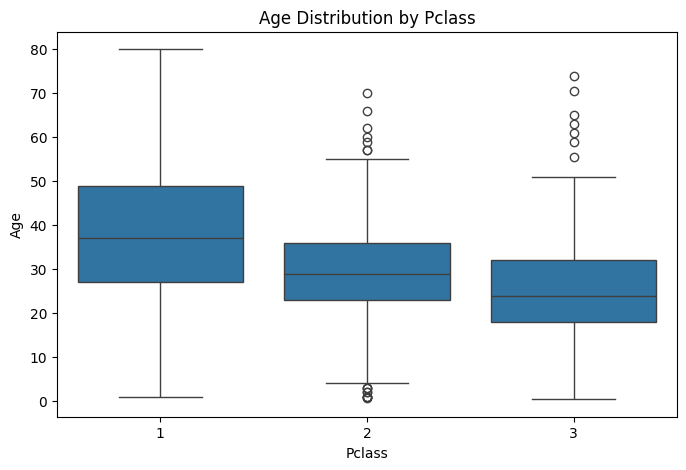

In [12]:
# Boxplot - Age by Pclass
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Age', data=train)
plt.title("Age Distribution by Pclass")
plt.show()


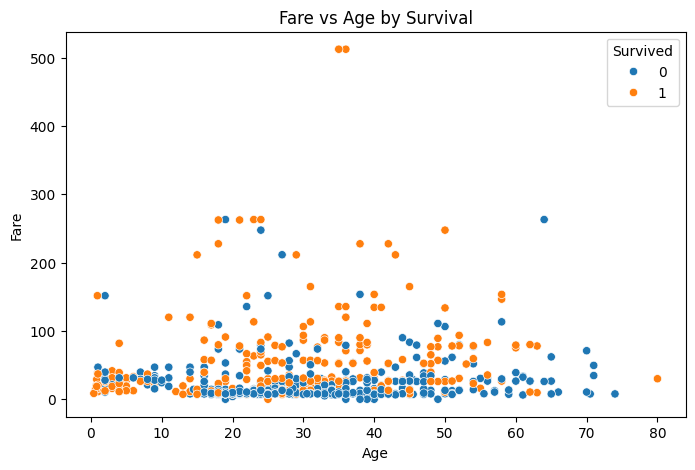

In [14]:

# Scatterplot - Fare vs Age by Survival
plt.figure(figsize=(8, 5))
sns.scatterplot(data=train, x='Age', y='Fare', hue='Survived')
plt.title("Fare vs Age by Survival")
plt.show()



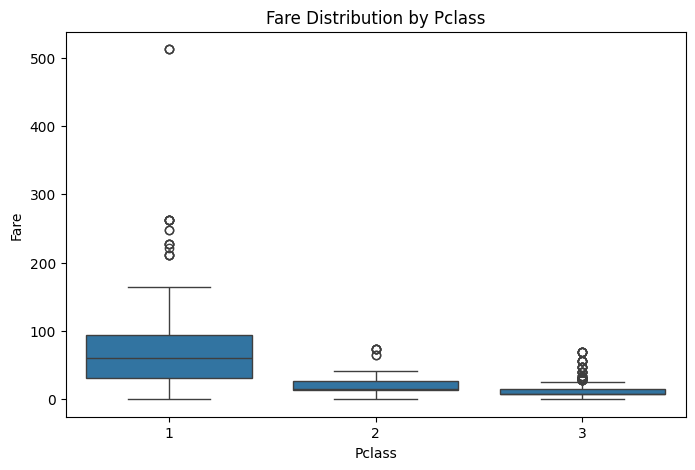

In [15]:
# Boxplot - Fare by Pclass
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Fare', data=train)
plt.title("Fare Distribution by Pclass")
plt.show()

In [18]:
summary = """
Summary of Titanic Dataset Analysis:

1. Gender: Female passengers had significantly higher survival rates than males.
2. Class: Passengers in 1st class had the best chances of survival.
3. Age: Younger passengers, especially children, survived more often.
4. Fare: Higher fare passengers generally had better chances of survival.
5. Embarked: Passengers who embarked at Cherbourg (C) had higher survival rates.
6. Family Influence: SibSp and Parch suggest some survival advantage with family.
"""
print(summary)



Summary of Titanic Dataset Analysis:

1. Gender: Female passengers had significantly higher survival rates than males.
2. Class: Passengers in 1st class had the best chances of survival.
3. Age: Younger passengers, especially children, survived more often.
4. Fare: Higher fare passengers generally had better chances of survival.
5. Embarked: Passengers who embarked at Cherbourg (C) had higher survival rates.
6. Family Influence: SibSp and Parch suggest some survival advantage with family.

